https://rhodesmill.org/skyfield/toc.html

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
%matplotlib widget



In [2]:
earth_radius = 6371 * 1e3

In [3]:
max_slant_angle = np.radians(60)
ang1 = np.linspace(-1, 1, 360) * max_slant_angle
ang2 = np.linspace(-1, 1, 360) * max_slant_angle
sat_alts = np.arange(250, 1000+1, 250) * 1e3
ang1_deg = np.degrees(ang1); ang2_deg = np.degrees(ang2)
ang1_mesh, ang2_mesh, sat_alt_mesh = np.meshgrid(ang1, ang2, sat_alts)
ang1_mesh_deg = np.degrees(ang1_mesh); ang2_mesh_deg = np.degrees(ang2_mesh)
sphere_x = (earth_radius + sat_alt_mesh) * np.cos(ang1_mesh) * np.cos(ang2_mesh)
sphere_y = (earth_radius + sat_alt_mesh) * np.cos(ang1_mesh) * np.sin(ang2_mesh)
sphere_z = (earth_radius + sat_alt_mesh) * np.sin(ang1_mesh)

sat_sphere = np.stack((sphere_x, sphere_y, sphere_z))
print(sat_sphere.shape)

(3, 360, 360, 4)


In [4]:
gs = np.array([earth_radius, 0, 0])
sat_vecs = sat_sphere - gs[:, np.newaxis, np.newaxis, np.newaxis]
sat_distance = np.linalg.norm(sat_vecs, axis=0)
print(sat_vecs.shape, sat_distance.shape)
print(f"Distance to satellite at 500 km altitude, zenith: {sat_distance[180, 180, 0] / 1e3:.1f} km")

(3, 360, 360, 4) (360, 360, 4)
Distance to satellite at 500 km altitude, zenith: 251.4 km


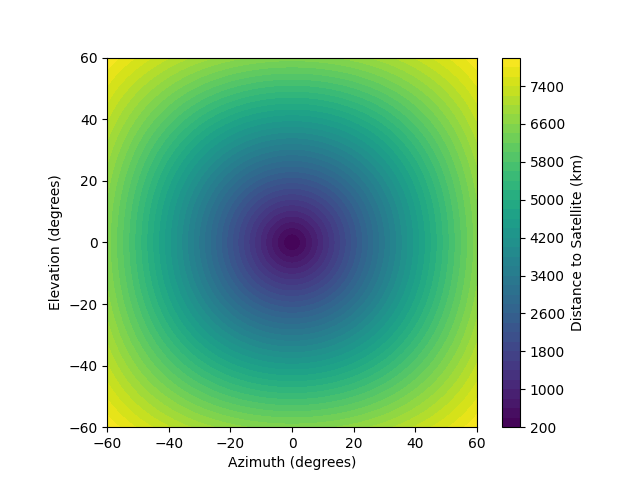

In [5]:
fig = plt.figure()
ax = plt.subplot(111)
dist_map = ax.contourf(ang1_mesh_deg[:, :, 0], ang2_mesh_deg[:, :, 0], sat_distance[:, :, 0] / 1e3, levels=50, cmap='viridis')
range_curve = ax.contour(ang1_mesh_deg[:, :, 0], ang2_mesh_deg[:, :, 0], sat_distance[:, :, 0] / 1e3, levels=[4], colors='white', linewidths=0.5)
fig.colorbar(dist_map, ax=ax, label='Distance to Satellite (km)')
ax.set_xlabel('Azimuth (degrees)')
ax.set_ylabel('Elevation (degrees)')
ax.set_aspect('equal')
plt.show()

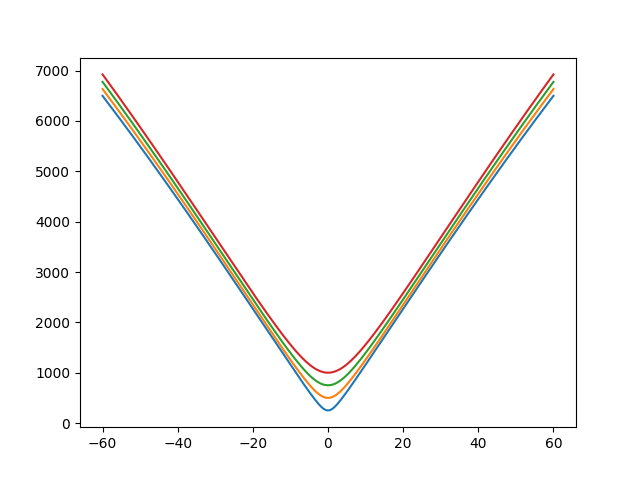

In [6]:
fig = plt.figure()
ax = plt.subplot(111)

for i, alt in enumerate(sat_alts):
  ax.plot(ang1_mesh_deg[180, :, i], sat_distance[:, 180, i] / 1e3, label=f'{alt/1e3:.0f} km')
  
ax.autoscale_view()
plt.show()
